In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from src.utils import compute_individual_expectation_values, build_hva_layers, build_sparse_hamiltonian,find_best_initial_params,test_energy_consistency,optimize_energy, compute_error, compute_energy

from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2, FakeAthensV2

from matplotlib import pyplot as plt
import sys
import numpy as np
from qiskit.quantum_info import Pauli, Statevector
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.visualization import plot_gate_map
from qiskit.transpiler import CouplingMap

import pickle
import pandas as pd
import dill
"""with open("WS_TestFramework_realBackend.dill", "rb") as f:
    globals().update(dill.load(f))"""

sys.path.append("../../pauli_lindblad_per/")
from tomography.experiment import SparsePauliTomographyExperiment as tomography

plt.style.use("ggplot")

Initial Error        : 0.10484684299231528
Exakte Energie       :  -7.819890870294845
Startparameter       : [-3.14159265 -1.57079633  1.57079633]
Optimierte Parameter : [-3.14159265 -1.57071519  1.57085478]
Minimaler Fehler     : 0.1048468493862667


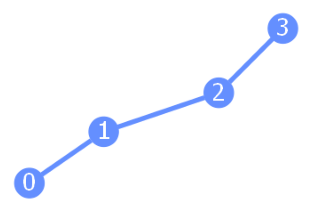

In [2]:
# Lineare Kopplung: 0–1–2–3
coupling = CouplingMap(couplinglist=[(0, 1), (1, 2), (2, 3), (1,0), (2,1), (3,2)])
backend = GenericBackendV2(num_qubits=4, coupling_map=coupling)

#backend = FakeAthensV2()

plot_gate_map(backend)

hx = 1
hz = 1
J=-1
H_sparse = build_sparse_hamiltonian(hx, hz, backend, J=J)

best_guess, energy_exact = find_best_initial_params(H_sparse, backend)

opt_params, min_error = optimize_energy(best_guess, H_sparse, backend, energy_exact)

print(f"Initial Error        : {compute_error(best_guess, H_sparse, backend, energy_exact, num_layers=1)}")
print("Exakte Energie       : ", energy_exact)
print("Startparameter       :",best_guess)
print("Optimierte Parameter :", opt_params)
print("Minimaler Fehler     :", min_error)

In [3]:
opt_params = [1,0.5,0.75]
expectation_values, paulis = compute_individual_expectation_values(opt_params, backend, hx, hz,J=J, num_layers=1)
pauli_list = paulis
print(pauli_list)
test_energy_consistency(opt_params, backend, hx=hx, hz=hz, J=J)

['IIZZ', 'IZZI', 'ZZII', 'IIIX', 'IIIZ', 'IIXI', 'IIZI', 'IXII', 'IZII', 'XIII', 'ZIII']
Energie direkt        : 1.9133669142
Energie aus Summe     : 1.9133669142+0.0000000000j
Relativer Fehler      : 0.00e+00


In [4]:
df = pd.DataFrame({
    'Pauli': paulis,
    'Expectation Value': expectation_values
})
df

,Pauli,Expectation Value
0,IIZZ,0.106795
1,IZZI,0.106795
2,ZZII,0.106795
3,IIIX,0.377697
4,IIIZ,0.326795
5,IIXI,0.085589
6,IIZI,0.326795
7,IXII,0.085589
8,IZII,0.326795
9,XIII,0.377697


In [5]:
inst_map = [0,1,2,3]
qc = build_hva_layers(opt_params, backend, num_layers=1)

qc.draw(fold=-1)

┌───┐┌─────────┐┌──────────┐                                                         
q_0: ┤ H ├┤ Rz(0.5) ├┤ Rx(0.75) ├──■─────────────■────────────────────────────────────────
     ├───┤├─────────┤├──────────┤┌─┴─┐┌───────┐┌─┴─┐                                      
q_1: ┤ H ├┤ Rz(0.5) ├┤ Rx(0.75) ├┤ X ├┤ Rz(1) ├┤ X ├──■─────────────■─────────────────────
     ├───┤├─────────┤├──────────┤└───┘└───────┘└───┘┌─┴─┐┌───────┐┌─┴─┐                   
q_2: ┤ H ├┤ Rz(0.5) ├┤ Rx(0.75) ├───────────────────┤ X ├┤ Rz(1) ├┤ X ├──■─────────────■──
     ├───┤├─────────┤├──────────┤                   └───┘└───────┘└───┘┌─┴─┐┌───────┐┌─┴─┐
q_3: ┤ H ├┤ Rz(0.5) ├┤ Rx(0.75) ├──────────────────────────────────────┤ X ├┤ Rz(1) ├┤ X ├
     └───┘└─────────┘└──────────┘                                      └───┘└───────┘└───┘

In [6]:
# --- 5. Simulator instanziieren ---
backend = FakeWashingtonV2()
noise_model = NoiseModel.from_backend(backend)
simulator = AerSimulator(noise_model=noise_model)

In [7]:
from src.calculate_runs import count_tomography_runs_from_repo, count_per_runs

# TOMOGRAPHY
res_tomo = count_tomography_runs_from_repo(
    qc=qc,
    inst_map=inst_map,
    backend=backend,
    used_qubits=inst_map,
    depths=[2,4,16,32,64],
    samples=100,
    single_samples=250,
    shots=1024   # optional
)
print("Tomography: ",res_tomo['backend_runs'])

# PER
res_per = count_per_runs(
    qc=qc,
    pauli_list=pauli_list,
    noise_strengths=[0,1,2],
    samples=1000,
    shots=1024   # optional
)
print("PER: ",res_per['backend_runs'])
print("Total: ",res_per['backend_runs'] + res_tomo['backend_runs'])

Tomography:  18432000
PER:  15360000
Total:  33792000


In [8]:
experiment = tomography(
    circuits = [qc], #list of circuits from which to get the layers requiring tomography
    inst_map = inst_map, #which physical qubits on the processor to map the qubits in the circuit
    backend = backend, #quantum backend
    used_qubits= inst_map
    )

experiment.generate(
    samples = 100, #Number of samples to take from the fidelity pair measurements
    single_samples = 250, #samples to take from the pair-breaking measurements
    depths = [2,4,16,32,64] #values of 2n to make the pair measurements. Numbers must be even and non-zero
    )

shots = 1024
def executor(circuits):
    return backend.run(circuits, shots = shots, noise_model=noise_model).result().get_counts()

c:\Users\kchar\OneDrive\Desktop\Uni\Hiwi_Orth\Qiskit\qiskit-venv\lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


KeyboardInterrupt: 

In [ ]:
#run the experiment
experiment.run(executor)
noisedataframe = experiment.analyze()

In [ ]:
layer1 = experiment.analysis.get_layer_data(0)
layer1.plot_infidelitites(plot_style = 2)

In [ ]:
layer1.plot_coeffs(plot_style = 2)

In [ ]:
layer2 = experiment.analysis.get_layer_data(1)
layer2.plot_infidelitites(plot_style = 2)

In [ ]:
layer2.plot_coeffs(plot_style = 2)

In [ ]:
# 2. PER-Experiment Setup
perexp = experiment.create_per_experiment([qc])

perexp.generate(
    expectations=pauli_list,
    samples=1000,
    noise_strengths=[0, 1, 2]
)

# NACH perexp.generate() - weitere Zelle:
per_stats = calculate_per_experiment_runs(perexp, shots=1024)
print(f"PER: {per_stats['circuits']} circuits") 
print(f"Total executions: {per_stats['total_executions']:,}")

# Oder schöne Zusammenfassung am Ende:
print_experiment_summary(experiment, perexp, shots=1024)

In [ ]:
# 3. Ausführen
perexp.run(executor)

In [ ]:
# 4. Analysieren
per_results = perexp.analyze()
result_1 = per_results[0].get_result(pauli_list[2]).plot()
print("Aus SV-Simulation: ",expectation_values[1])

In [ ]:
# Compare absolute vs relative errors
for k in range(len(pauli_list)):
    exact = expectation_values[k]
    calc = per_results[0].get_result(pauli_list[k]).get_expectations()[0]
    abs_error = abs(exact - calc)
    rel_error = abs_error / abs(exact) if exact != 0 else float('inf')
    
    print(f"{pauli_list[k]}: Exact={exact:.4f}, Calc={calc:.4f}")
    print(f"  Absolute error: {abs_error:.6f}")
    print(f"  Relative error: {rel_error*100:.2f}%")
    print()

In [ ]:
import dill

to_save = {
    'experiment': experiment,
    'noisedataframe': noisedataframe,
    'expectation_values': expectation_values,
    'backend': backend,
    'simulator': simulator,
    'pauli_list': pauli_list,
    'perexp': perexp
}

with open("WS_TestFramework_realNoisemodel_fakeParameters.dill", "wb") as f:
    dill.dump(to_save, f)